Primero obtenemos los datos de la API de spotify (en caso de tener una cuenta premium)

In [ ]:
import os
import pandas as pd
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

# 1. Configurar las credenciales de la API de Spotify
# (Asegúrate de reemplazar 'TUS_CLIENT_ID' y 'TUS_CLIENT_SECRET' con tus credenciales reales)
os.environ["SPOTIPY_CLIENT_ID"] = "TUS_CLIENT_ID"
os.environ["SPOTIPY_CLIENT_SECRET"] = "TUS_CLIENT_SECRET"

# Inicializar el cliente de Spotify usando Client Credentials
sp = spotipy.Spotify(
    auth_manager=SpotifyClientCredentials()
)  #

# Lista de artistas y IDs (idéntica a tu código de R)
artists = [
    "Linkin Park",
    "Cruz Cafuné",
    "Imagine Dragons",
    "Melendi",
    "La Oreja de Van Gogh",
    "Reneé Rapp",
    "Julio Iglesias",
    "Morat",
    "Creedence Clearwater Revival",
    "Three six mafia",
    "Desakato",
    "Los rebujitos",
    "Raule",
    "C. Tangana",
    "6euEaUskx8IOFgR6Iq9wuF",  # Henko
    "Belén Aguilera",
    "Pablo Alborán",
    "Estopa",
    "Dei V",
    "Bruno Mars",
]

all_tracks_data = []

# 2. Iterar sobre cada artista o ID para obtener sus canciones y características de audio
for artist_query in artists:
  print(f"Procesando: {artist_query}")

  try:
    # Determinar si el elemento es un ID de Spotify o el nombre del artista
    if len(artist_query) == 22 and not " " in artist_query:
      artist_id = artist_query
    else:
      # Buscar el artista por nombre para obtener su ID
      results = sp.search(q=artist_query, type="artist", limit=1)
      items = results["artists"]["items"]
      if not items:
        print(f"No se encontró el artista: {artist_query}")
        continue
      artist_id = items["id"]

    # Obtener las canciones principales del artista (Top Tracks para España 'ES' o general)
    top_tracks = sp.artist_top_tracks(artist_id, country="ES")["tracks"]

    if not top_tracks:
      continue

    track_ids = [track["id"] for track in top_tracks]

    # Obtener las características de audio (audio features) de las canciones
    audio_features = sp.audio_features(track_ids)

    # Combinar la información básica de la pista con sus características de audio
    for track, features in zip(top_tracks, audio_features):
      if features is None:
        continue

      # Crear un diccionario plano con la información relevante
      track_data = {
          "artist_search": artist_query,
          "track_name": track.get("name"),
          "track_id": track.get("id"),
          "popularity": track.get("popularity"),
          "album_name": track.get("album", {}).get("name"),
          # Añadir las variables de audio features
          "danceability": features.get("danceability"),
          "energy": features.get("energy"),
          "key": features.get("key"),
          "loudness": features.get("loudness"),
          "mode": features.get("mode"),
          "speechiness": features.get("speechiness"),
          "acousticness": features.get("acousticness"),
          "instrumentalness": features.get("instrumentalness"),
          "liveness": features.get("liveness"),
          "valence": features.get("valence"),
          "tempo": features.get("tempo"),
          "duration_ms": features.get("duration_ms"),
          "time_signature": features.get("time_signature"),
      }
      all_tracks_data.append(track_data)

  except Exception as e:
    print(f"Error procesando {artist_query}: {e}")

# 3. Convertir la lista acumulada en un DataFrame de Pandas
canciones_df = pd.DataFrame(all_tracks_data)

# 4. Asegurarse de que la carpeta exterior 'data' exista, si no, crearla
output_dir = "../data"
os.makedirs(output_dir, exist_ok=True)

# Guardar el DataFrame como CSV en la ruta '../data/DatosPractica3.csv'
output_path = os.path.join(output_dir, "DatosPractica3.csv")
canciones_df.to_csv(output_path, index=False)

print(f"\n¡Proceso finalizado! Archivo guardado correctamente en: {output_path}")

Procesando: Linkin Park


HTTP Error for GET to https://api.spotify.com/v1/search with Params: {'q': 'Linkin Park', 'limit': 1, 'offset': 0, 'type': 'artist', 'market': None} returned 403 due to Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again.
HTTP Error for GET to https://api.spotify.com/v1/search with Params: {'q': 'Cruz Cafuné', 'limit': 1, 'offset': 0, 'type': 'artist', 'market': None} returned 403 due to Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again.
HTTP Error for GET to https://api.spotify.com/v1/search with Params: {'q': 'Imagine Dragons', 'limit': 1, 'offset': 0, 'type': 'artist', 'market': None} returned 403 due to Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again.
HTTP Erro

Error procesando Linkin Park: http status: 403, code: -1 - https://api.spotify.com/v1/search?q=Linkin+Park&limit=1&offset=0&type=artist:
 Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again., reason: None
Procesando: Cruz Cafuné
Error procesando Cruz Cafuné: http status: 403, code: -1 - https://api.spotify.com/v1/search?q=Cruz+Cafun%C3%A9&limit=1&offset=0&type=artist:
 Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again., reason: None
Procesando: Imagine Dragons
Error procesando Imagine Dragons: http status: 403, code: -1 - https://api.spotify.com/v1/search?q=Imagine+Dragons&limit=1&offset=0&type=artist:
 Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again., reason: None

HTTP Error for GET to https://api.spotify.com/v1/search with Params: {'q': 'Reneé Rapp', 'limit': 1, 'offset': 0, 'type': 'artist', 'market': None} returned 403 due to Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again.
HTTP Error for GET to https://api.spotify.com/v1/search with Params: {'q': 'Julio Iglesias', 'limit': 1, 'offset': 0, 'type': 'artist', 'market': None} returned 403 due to Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again.
HTTP Error for GET to https://api.spotify.com/v1/search with Params: {'q': 'Morat', 'limit': 1, 'offset': 0, 'type': 'artist', 'market': None} returned 403 due to Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again.
HTTP Error for GE

Error procesando Reneé Rapp: http status: 403, code: -1 - https://api.spotify.com/v1/search?q=Rene%C3%A9+Rapp&limit=1&offset=0&type=artist:
 Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again., reason: None
Procesando: Julio Iglesias
Error procesando Julio Iglesias: http status: 403, code: -1 - https://api.spotify.com/v1/search?q=Julio+Iglesias&limit=1&offset=0&type=artist:
 Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again., reason: None
Procesando: Morat
Error procesando Morat: http status: 403, code: -1 - https://api.spotify.com/v1/search?q=Morat&limit=1&offset=0&type=artist:
 Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again., reason: None
Procesando: Creedence 

HTTP Error for GET to https://api.spotify.com/v1/search with Params: {'q': 'Desakato', 'limit': 1, 'offset': 0, 'type': 'artist', 'market': None} returned 403 due to Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again.
HTTP Error for GET to https://api.spotify.com/v1/search with Params: {'q': 'Los rebujitos', 'limit': 1, 'offset': 0, 'type': 'artist', 'market': None} returned 403 due to Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again.
HTTP Error for GET to https://api.spotify.com/v1/search with Params: {'q': 'Raule', 'limit': 1, 'offset': 0, 'type': 'artist', 'market': None} returned 403 due to Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again.
HTTP Error for GET t

Error procesando Desakato: http status: 403, code: -1 - https://api.spotify.com/v1/search?q=Desakato&limit=1&offset=0&type=artist:
 Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again., reason: None
Procesando: Los rebujitos
Error procesando Los rebujitos: http status: 403, code: -1 - https://api.spotify.com/v1/search?q=Los+rebujitos&limit=1&offset=0&type=artist:
 Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again., reason: None
Procesando: Raule
Error procesando Raule: http status: 403, code: -1 - https://api.spotify.com/v1/search?q=Raule&limit=1&offset=0&type=artist:
 Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again., reason: None
Procesando: C. Tangana
Error proce

HTTP Error for GET to https://api.spotify.com/v1/search with Params: {'q': 'Belén Aguilera', 'limit': 1, 'offset': 0, 'type': 'artist', 'market': None} returned 403 due to Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again.
HTTP Error for GET to https://api.spotify.com/v1/search with Params: {'q': 'Pablo Alborán', 'limit': 1, 'offset': 0, 'type': 'artist', 'market': None} returned 403 due to Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again.
HTTP Error for GET to https://api.spotify.com/v1/search with Params: {'q': 'Estopa', 'limit': 1, 'offset': 0, 'type': 'artist', 'market': None} returned 403 due to Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again.
HTTP Error fo

Error procesando Belén Aguilera: http status: 403, code: -1 - https://api.spotify.com/v1/search?q=Bel%C3%A9n+Aguilera&limit=1&offset=0&type=artist:
 Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again., reason: None
Procesando: Pablo Alborán
Error procesando Pablo Alborán: http status: 403, code: -1 - https://api.spotify.com/v1/search?q=Pablo+Albor%C3%A1n&limit=1&offset=0&type=artist:
 Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again., reason: None
Procesando: Estopa
Error procesando Estopa: http status: 403, code: -1 - https://api.spotify.com/v1/search?q=Estopa&limit=1&offset=0&type=artist:
 Active premium subscription required for the owner of the app. When the subscription status changes, it can take a few hours before requests are allowed again., reason: None
Procesand

Tras esto leemos el fichero de datos csv y visualizamos que se haya guardado correctamente

In [2]:
import pandas as pd

# Cargar el archivo CSV guardado en la carpeta data
df = pd.read_csv("../data/DatosPractica3.csv")

# Mostrar las primeras 5 filas del dataset
display(df.head())

print(df.columns)
print(df.shape)

,artist_name,artist_id,album_id,album_type,album_release_date,album_release_year,album_release_date_precision,danceability,energy,key,...,track_name,track_number,type,track_uri,is_local,external_urls.spotify,album_name,key_name,mode_name,key_mode
0,Linkin Park,6XyY86QOPPrYVGvF9ch6wz,494aUGKXMH5ruXtR3O1a3H,album,2024-06-28,2024.0,day,0.622,0.632,9,...,Crawling (Instrumental),1,track,spotify:track:4XaV4XMROzY1G242gB3Q4K,False,https://open.spotify.com/track/4XaV4XMROzY1G24...,Papercuts: Instrumentals,A,major,A major
1,Linkin Park,6XyY86QOPPrYVGvF9ch6wz,494aUGKXMH5ruXtR3O1a3H,album,2024-06-28,2024.0,day,0.562,0.929,4,...,Faint (Instrumental),2,track,spotify:track:46ppIcCWeyCeNS6BbveSc0,False,https://open.spotify.com/track/46ppIcCWeyCeNS6...,Papercuts: Instrumentals,E,major,E major
2,Linkin Park,6XyY86QOPPrYVGvF9ch6wz,494aUGKXMH5ruXtR3O1a3H,album,2024-06-28,2024.0,day,0.728,0.375,2,...,Numb / Encore (Instrumental),3,track,spotify:track:4ySeTJOYb31uzSdIMw0U3x,False,https://open.spotify.com/track/4ySeTJOYb31uzSd...,Papercuts: Instrumentals,D,major,D major
3,Linkin Park,6XyY86QOPPrYVGvF9ch6wz,494aUGKXMH5ruXtR3O1a3H,album,2024-06-28,2024.0,day,0.499,0.816,9,...,Papercut (Instrumental),4,track,spotify:track:4B1Uaz5w9HGXtIigc3zyQa,False,https://open.spotify.com/track/4B1Uaz5w9HGXtIi...,Papercuts: Instrumentals,A,major,A major
4,Linkin Park,6XyY86QOPPrYVGvF9ch6wz,494aUGKXMH5ruXtR3O1a3H,album,2024-06-28,2024.0,day,0.515,0.833,4,...,Breaking the Habit (Instrumental),5,track,spotify:track:3zruk8xsxvYcLOsYjFNl8E,False,https://open.spotify.com/track/3zruk8xsxvYcLOs...,Papercuts: Instrumentals,E,minor,E minor


Index(['artist_name', 'artist_id', 'album_id', 'album_type',
       'album_release_date', 'album_release_year',
       'album_release_date_precision', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'track_id', 'analysis_url',
       'time_signature', 'disc_number', 'duration_ms', 'explicit',
       'track_href', 'track_name', 'track_number', 'type', 'track_uri',
       'is_local', 'external_urls.spotify', 'album_name', 'key_name',
       'mode_name', 'key_mode'],
      dtype='str')
(4023, 35)


Nos quedamos con las variables que pueden aportar información a la hora de predecir el cantante o grupo y también eliminamos aquellas que repitan información

In [3]:
import pandas as pd

# 1. Cargar el dataset original
df = pd.read_csv("../data/DatosPractica3.csv")

# 2. Eliminar estrictamente solo los IDs aleatorios y enlaces técnicos
columnas_a_eliminar = [
    "artist_id",  # <- ¡Clave! Nunca debe estar o el modelo adivina por arte de magia
    "track_id",
    "album_id",
    "track_href",
    "analysis_url",
    "external_urls.spotify",
    "track_uri",
    "type",
    "is_local",
    "disc_number",
    "album_release_date_precision",
    "album_release_year"
]

df_clean = df.drop(columns=columnas_a_eliminar)

# 3. Limpiar valores nulos en las variables principales
df_clean = df_clean.dropna(
    subset=["artist_name", "track_name", "album_name"]
)

print(f"Número total de variables conservadas: {df_clean.shape[1]}")
print(
    "¡Perfecto! Ahora tenemos las características de audio, los títulos y los"
    " datos del álbum listos."
)

print(df_clean.columns)

Número total de variables conservadas: 23
¡Perfecto! Ahora tenemos las características de audio, los títulos y los datos del álbum listos.
Index(['artist_name', 'album_type', 'album_release_date', 'danceability',
       'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'duration_ms', 'explicit', 'track_name', 'track_number', 'album_name',
       'key_name', 'mode_name', 'key_mode'],
      dtype='str')


Ahora vamos a observar si existen valores faltantes en alguna variable

In [4]:
print(df_clean.isnull().sum())

artist_name           0
album_type            0
album_release_date    0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
time_signature        0
duration_ms           0
explicit              0
track_name            0
track_number          0
album_name            0
key_name              0
mode_name             0
key_mode              0
dtype: int64


No existe ningún valor faltante por lo que no hay que decidir entre eliminar o imputar dichos valores

Ahora vamos a ver si existen valores fuera de rango para las variables numéricas.

In [5]:
# Definir los rangos lógicos esperados para las variables numéricas principales
rangos_validos = {
    "danceability": (0.0, 1.0),
    "energy": (0.0, 1.0),
    "speechiness": (0.0, 1.0),
    "acousticness": (0.0, 1.0),
    "instrumentalness": (0.0, 1.0),
    "liveness": (0.0, 1.0),
    "valence": (0.0, 1.0),
    "key": (0, 11),
    "mode": (0, 1),
    "tempo": (0.0, 300.0),  # Permite tempo 0 para interludios, pero vigila máximos
    "duration_ms": (
        5000,
        1800000,
    ),  # Desde 5 segundos hasta 30 minutos por seguridad
}

# Comprobar si alguna fila viola estos límites
fuera_de_rango = {}
for col, (min_val, max_val) in rangos_validos.items():
    if col in df_clean.columns:
        invalidos = df_clean[
            (df_clean[col] < min_val) | (df_clean[col] > max_val)
        ]
        if len(invalidos) > 0:
            fuera_de_rango[col] = len(invalidos)

print("Variables con valores fuera de rango:", fuera_de_rango)

Variables con valores fuera de rango: {}


Comprobamos que no haya ninguna variable categórica con valores inesperados.

In [6]:
# Lista de las columnas categóricas que quieres revisar
columnas_a_revisar = [
    "album_type",
    "explicit",
    "mode_name",
    "key_name",
    "key_mode",
]

# Imprimir los valores únicos de cada una
for col in columnas_a_revisar:
    if col in df_clean.columns:
        print(f"Valores distintos para '{col}': {df_clean[col].unique()}")

Valores distintos para 'album_type': <ArrowStringArray>
['album']
Length: 1, dtype: str
Valores distintos para 'explicit': [False  True]
Valores distintos para 'mode_name': <ArrowStringArray>
['major', 'minor']
Length: 2, dtype: str
Valores distintos para 'key_name': <ArrowStringArray>
['A', 'E', 'D', 'D#', 'B', 'A#', 'C#', 'G#', 'F', 'C', 'G', 'F#']
Length: 12, dtype: str
Valores distintos para 'key_mode': <ArrowStringArray>
[ 'A major',  'E major',  'D major',  'E minor', 'D# minor',  'B major',
 'A# minor', 'C# minor', 'G# major',  'A minor',  'F major',  'F minor',
  'C major',  'G major', 'G# minor', 'C# major', 'F# minor', 'A# major',
 'F# major',  'B minor',  'G minor',  'C minor', 'D# major',  'D minor']
Length: 24, dtype: str


Se puede observar que la variable categórica album_type tiene el mismo valor para todas las filas por lo que no aportará nada de información al modelo para predecir de que cantante es cada canción por lo que se eliminará del dataset

In [7]:
# Eliminar la columna del álbum (en este caso, 'album_type') de df_clean
df_clean = df_clean.drop(columns=["album_type"], errors="ignore")
print(f"Número total de variables conservadas: {df_clean.shape[1]}")
print(df_clean.columns)

Número total de variables conservadas: 22
Index(['artist_name', 'album_release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'duration_ms',
       'explicit', 'track_name', 'track_number', 'album_name', 'key_name',
       'mode_name', 'key_mode'],
      dtype='str')


Ahora comprobamos la correlación entre todas las variables numéricas para ver si alguna de ellas es redundante

                  danceability    energy       key  loudness      mode  \
danceability          1.000000  0.210387  0.049932  0.330341 -0.090165   
energy                0.210387  1.000000  0.055198  0.756484 -0.090642   
key                   0.049932  0.055198  1.000000  0.059623 -0.183691   
loudness              0.330341  0.756484  0.059623  1.000000 -0.078694   
mode                 -0.090165 -0.090642 -0.183691 -0.078694  1.000000   
speechiness           0.203296  0.026754  0.027717  0.034534 -0.076856   
acousticness         -0.205950 -0.613968  0.001318 -0.488432  0.004862   
instrumentalness     -0.167144 -0.004696  0.002420 -0.158356 -0.006291   
liveness             -0.226551  0.169425 -0.025495  0.013015  0.021985   
valence               0.436291  0.334858  0.047950  0.231244 -0.064656   
tempo                 0.043356  0.177199  0.043393  0.196479 -0.012210   
time_signature        0.192506  0.119732  0.017463  0.105513 -0.005979   
duration_ms          -0.049385  0.0401

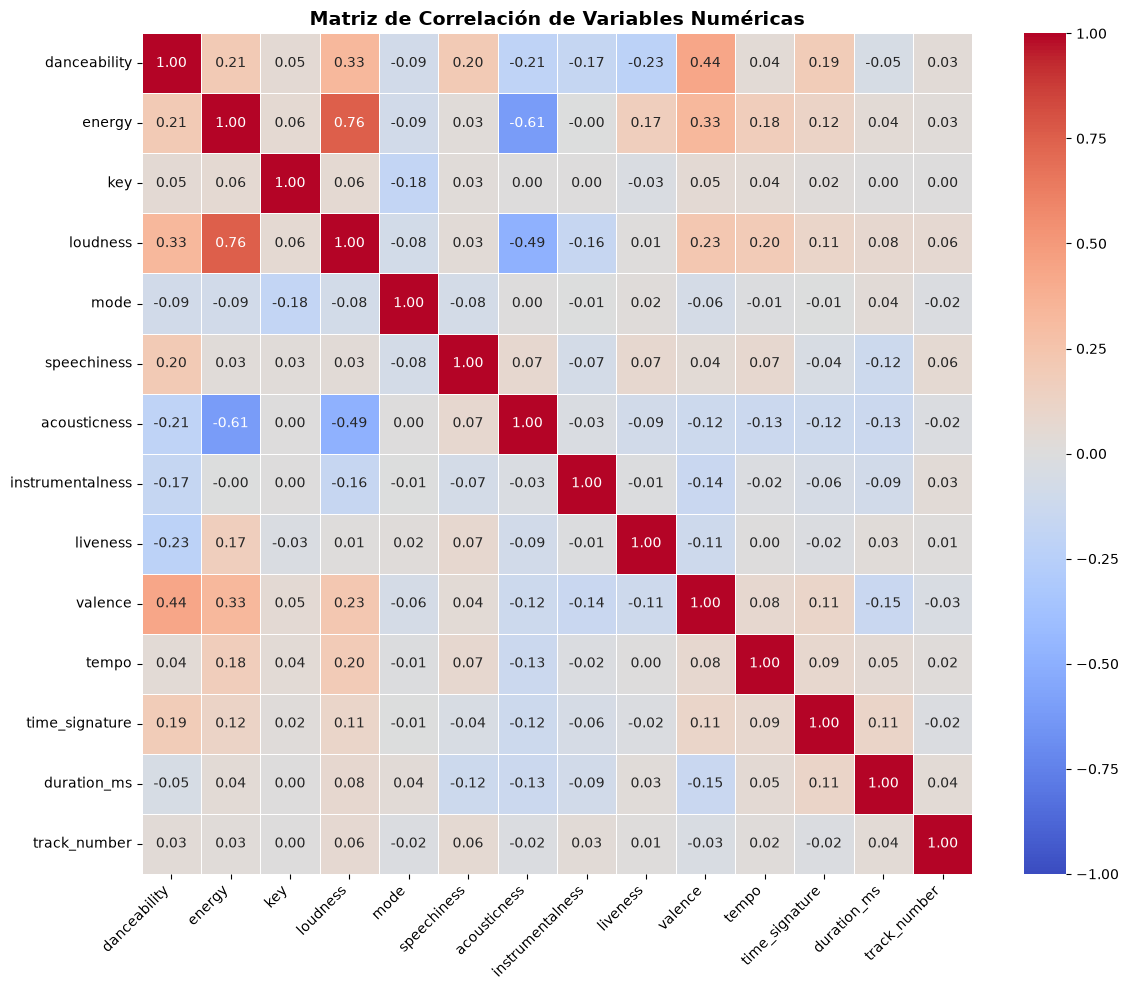

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Seleccionar únicamente las columnas numéricas de df_clean
df_numericas = df_clean.select_dtypes(include=["float64", "int64"])

# 2. Calcular la matriz de correlación (método de Pearson por defecto)
matriz_correlacion = df_numericas.corr()

# 3. Mostrar la matriz en formato tabular por consola (opcional)
print(matriz_correlacion)

# 4. Generar un mapa de calor (Heatmap) visual muy intuitivo
plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title(
    "Matriz de Correlación de Variables Numéricas",
    fontsize=14,
    fontweight="bold",
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Podemos observar:
- Energy y Loudness: Tienen una correlación positiva muy alta de 0.76. Esto tiene total sentido musical y técnico: las canciones con mayor nivel de energía suelen estar masterizadas con un volumen aparente más alto y comprimido. Si usaras modelos lineales, convendría tener esto en cuenta por la redundancia.
- Energy y Acousticness: Presentan una fuerte correlación negativa de -0.61. Indica que cuanta más acústica sea una canción (instrumentos reales sin amplificación eléctrica), menor energía y estridencia digital tendrá.
- Loudness y Acousticness: También muestran una correlación negativa moderada de -0.49, reforzando la idea de que los temas acústicos suenan menos comprimidos y con menor volumen en la mezcla de Spotify.

Además existen otras relaciones menos fuertes como:
- Valence y Danceability: Tienen una correlación positiva de 0.44. Esto refleja que las canciones más alegres o positivas (valence) tienden a ser también las más bailables y rítmicas.
- Valence y Energy: Muestran una correlación de 0.33, lo que indica que la positividad musical suele ir acompañada de una intensidad energética elevada.
- Danceability y Loudness: Correlación positiva de 0.33, sugiriendo que los ritmos muy marcados suelen apoyarse en producciones potentes en decibelios.

Ahora vamos a ver cuantas canciones tiene cada cantante para ver si hay que corregir un posible desequilibrio de clases

C:\Users\danie\AppData\Local\Temp\ipykernel_9900\3419786793.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_artistas.values, y=conteo_artistas.index, palette='viridis')


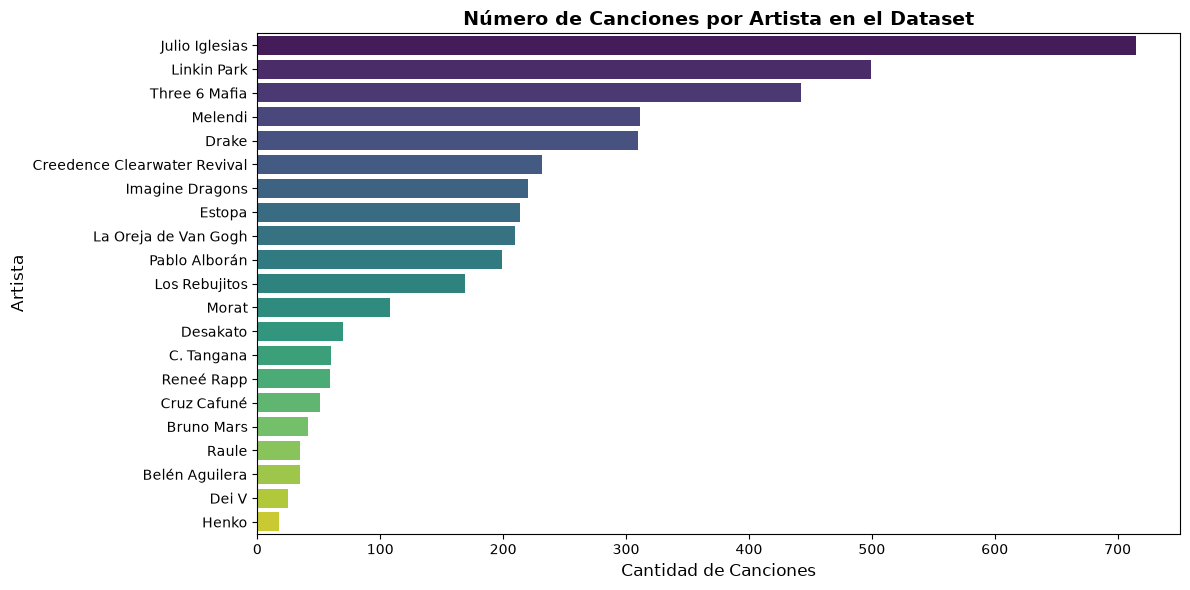


================ CONTEO DE CANCIONES POR ARTISTA ================
                     Artista  Número de Canciones
              Julio Iglesias                  715
                 Linkin Park                  499
               Three 6 Mafia                  442
                     Melendi                  311
                       Drake                  310
Creedence Clearwater Revival                  232
             Imagine Dragons                  220
                      Estopa                  214
        La Oreja de Van Gogh                  210
               Pablo Alborán                  199
               Los Rebujitos                  169
                       Morat                  108
                    Desakato                   70
                  C. Tangana                   60
                  Reneé Rapp                   59
                 Cruz Cafuné                   51
                  Bruno Mars                   41
                       Raule     

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- GRÁFICO DE CANCIONES POR CANTANTE ---
plt.figure(figsize=(12, 6))

# Contar cuántas canciones hay por cada artista en el DataFrame limpio
conteo_artistas = df_clean['artist_name'].value_counts()

# Crear un gráfico de barras horizontales usando seaborn
sns.barplot(x=conteo_artistas.values, y=conteo_artistas.index, palette='viridis')

# Personalizar el gráfico
plt.title('Número de Canciones por Artista en el Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Canciones', fontsize=12)
plt.ylabel('Artista', fontsize=12)
plt.tight_layout()

# Mostrar la gráfica
plt.show()

# --- TABLA CON EL NÚMERO EXACTO DE CANCIONES POR ARTISTA ---
conteo_artistas = df_clean['artist_name'].value_counts().reset_index()
conteo_artistas.columns = ['Artista', 'Número de Canciones']

print("\n================ CONTEO DE CANCIONES POR ARTISTA ================")
print(conteo_artistas.to_string(index=False))
print("-----------------------------------------------------------------")
print(conteo_artistas.describe()) # Muestra estadísticas rápidas (media, mínimo, máximo, etc.)